# Geopandas Intro

In [1]:
# Import packages
import os
import geopandas as gpd
import matplotlib.pyplot as plt

Reproducible File Paths similar to `here()` in R

In [2]:
# Create reproducible file path
fp = os.path.join('data','gbif_sus_scrofa_california','gbif_sus_scrofa_california.shp')
fp

'data/gbif_sus_scrofa_california/gbif_sus_scrofa_california.shp'

## Loading & Exploring

In [3]:
# Load data
pigs = gpd.read_file(fp)
pigs.head()

,gbifID,species,state,individual,day,month,year,inst,collection,catalogNum,identified,geometry
0,899953814,Sus scrofa,California,NaN,22.0,3.0,2014.0,iNaturalist,Observations,581956,edwardrooks,POINT (-121.53812 37.08846)
1,899951348,Sus scrofa,California,NaN,9.0,6.0,2007.0,iNaturalist,Observations,576047,Bruce Freeman,POINT (-120.54942 35.47354)
2,896560733,Sus scrofa,California,NaN,20.0,12.0,1937.0,MVZ,Hild,MVZ:Hild:195,"Museum of Vertebrate Zoology, University of Ca...",POINT (-122.27063 37.87610)
3,896559958,Sus scrofa,California,NaN,1.0,4.0,1969.0,MVZ,Hild,MVZ:Hild:1213,"Museum of Vertebrate Zoology, University of Ca...",POINT (-121.82297 38.44543)
4,896559722,Sus scrofa,California,NaN,1.0,1.0,1961.0,MVZ,Hild,MVZ:Hild:1004,"Museum of Vertebrate Zoology, University of Ca...",POINT (-121.74559 38.54882)


In [4]:
fp2 = os.path.join('data', 'ca_state_boundary', 'ca_state_boundary.shp')
ca_state = gpd.read_file(fp2)

In [5]:
type(pigs)

geopandas.geodataframe.GeoDataFrame

In [6]:
# Check datatypes
pigs.dtypes

gbifID           int64
species         object
state           object
individual     float64
day            float64
month          float64
year           float64
inst            object
collection      object
catalogNum      object
identified      object
geometry      geometry
dtype: object

In [7]:
# Check geom types in geometry column
pigs.geom_type.unique()

array(['Point', None], dtype=object)

## Coordinate Reference Systems (CRS)

In [8]:
# Check gdf crs
pigs.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [9]:
# Examine CRS details
print('Ellipsoid: ', pigs.crs.ellipsoid) # type: ignore
print('Datum: ', pigs.crs.datum) # type: ignore
print('Is geographic?: ', pigs.crs.is_geographic) # type: ignore
print('Is projected?: ', pigs.crs.is_projected) # type: ignore

Ellipsoid:  WGS 84
Datum:  World Geodetic System 1984 ensemble
Is geographic?:  True
Is projected?:  False


## Extent

In [10]:
# Show pigs total extent
pigs.total_bounds

array([-124.29448 ,   32.593433, -115.4356  ,   40.934296])

In [11]:
# Show ca state crs and total extent
print(f'CRS: {ca_state.crs}\n')
print(ca_state.total_bounds)

CRS: EPSG:4326

[-124.48201686   32.52883674 -114.13122248   42.00950827]


## Data Wrangling

Data wrangling GDFs are the same as regular pandas dataframes

In [12]:
# Count frequency of values in year column and sort to year ascending
pigs['year'].value_counts().sort_index()

year
1818.0     31
1910.0      1
1925.0      1
1927.0      4
1929.0      3
         ... 
2019.0    101
2020.0    159
2021.0    164
2022.0    185
2023.0     98
Name: count, Length: 61, dtype: int64

In [13]:
# Subset gdf to years > 2020
pigs_recent = pigs[pigs['year'] >= 2020]

# Check subset rows
if len(pigs) > len(pigs_recent):
    print("Original df has more rows. Subset worked")
else: 
    print("Subset is same length. Subset did not work")

Original df has more rows. Subset worked


## Plot with matplotlib

![](https://meds-eds-220.github.io/MEDS-eds-220-course/book/images/lesson-10/matplotlib_figure_axes_axis.png)

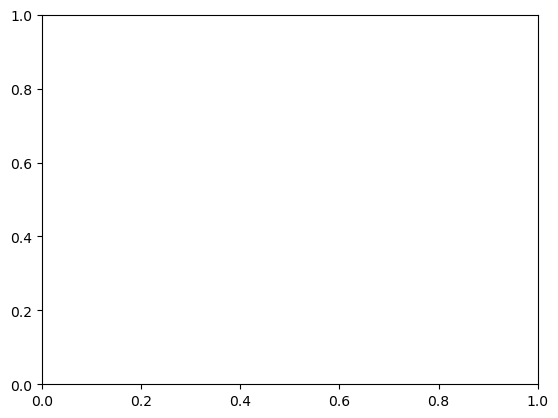

In [14]:
# Initialize empty subplot
fig, ax = plt.subplots()
plt.show()

Adding first layer onto ax

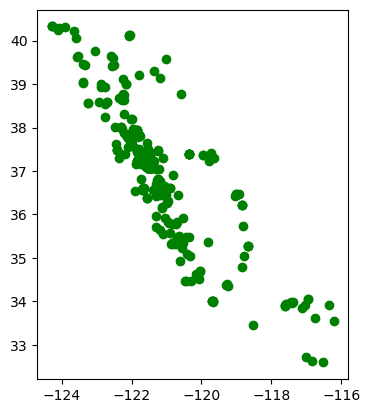

In [15]:
fig, ax = plt.subplots()

# Plotting recent pig points
pigs_recent.plot(ax=ax, color='green')
plt.show()

More customization

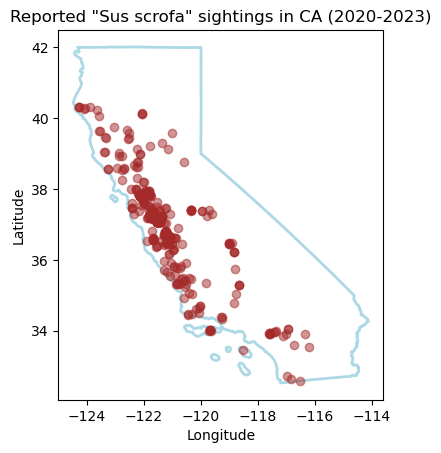

In [16]:
# Initialize empty figure
fig, ax = plt.subplots()

# Add california state boundary to axis
ca_state.plot(ax=ax,
              facecolor='white',
              edgecolor='lightblue',
              linewidth=2)
# Add recent pig data to axis
pigs_recent.plot(ax=ax,         # Add plot to axis
                 alpha=0.5,     # Adjust transparency
                 color='brown'  # Update point color
                 )

# Update axis 
ax.set_title('Reported "Sus scrofa" sightings in CA (2020-2023)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Display figure
plt.show()

Map Summary: 

Pig observations are mainly concentrated in the central/northern portion of California and little sightings reported in Southern California. Some biases and limitations come from how the data was collected. Observations were taken by community volunteers (I think) and these observations could be biased to cities where more people or more community volunteers exist.